In [122]:
# from sklearn.preprocessing import StandardScaler
import pandas as pd
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import plotly.express as px

%matplotlib inline

sns.set_theme('notebook', palette='muted')
sys.path.append(r"D:\HopeAI\Assignments\MyModules")

from data_analysis_utils import Univariate, Preprocessing

dataset = pd.read_csv(r"D:\HopeAI\Assignments\ML and DS Capstone\2. Data Preprocessing\PreStockFeatures.csv")
dataset


,Stock,Sector,Industry,Market Cap,Year,Total_Annual_Return,Avg_Monthly_Return,Std_Monthly_Return,Max_Drawdown,Std_Daily_Return,Pos_Days_Pct,Neg_Days_Pct,Avg_Daily_TR,Max_Daily_TR,Avg_Volume,Volume_Spike_Pct,12M_Momentum,Months_Pos_Pct,Beta_vs_NIFTY,Corr_with_NIFTY
0,ADANIENT,Energy,Thermal Coal,2994291081216,2014,84.785613,7.637515,14.186042,22.867706,3.010790,52.674897,46.090535,2.352871,13.486429,1.861417e+07,8.196721,107.917632,63.636364,1.598832,0.426155
1,ADANIENT,Energy,Thermal Coal,2994291081216,2015,-37.685498,-3.887377,19.560876,68.997003,4.156785,45.714286,52.653061,3.742656,239.273886,1.120364e+07,7.317073,-51.324566,54.545455,1.850348,0.457929
2,ADANIENT,Energy,Thermal Coal,2994291081216,2016,-14.119856,1.611336,15.492383,34.794663,2.639648,53.469388,45.306122,1.581010,4.432787,6.074467e+06,6.097561,6.215522,54.545455,1.649825,0.597262
3,ADANIENT,Energy,Thermal Coal,2994291081216,2017,117.329561,6.434280,8.526439,28.780005,3.281672,56.680162,42.510121,2.889061,19.576553,1.295658e+07,8.064516,91.893377,81.818182,1.912510,0.332076
4,ADANIENT,Energy,Thermal Coal,2994291081216,2018,78.500944,5.578514,26.632411,43.633455,3.637141,54.693878,45.306122,6.293391,30.900989,1.475299e+07,11.382114,39.024769,36.363636,2.142941,0.478182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,WIPRO,Technology,Information Technology Services,2532097654784,2020,56.564122,5.078310,11.196238,36.623083,2.500823,52.000000,47.200000,3.742075,16.643016,2.239159e+07,9.163347,63.112320,63.636364,0.670407,0.529060
480,WIPRO,Technology,Information Technology Services,2532097654784,2021,84.735387,5.200053,6.752821,12.734524,1.763293,57.085020,42.914980,6.545712,21.253327,2.143325e+07,10.080645,71.177270,72.727273,0.849918,0.476230
481,WIPRO,Technology,Information Technology Services,2532097654784,2022,-44.808074,-3.105960,6.336069,47.492937,1.706648,47.368421,52.631579,4.864650,17.585685,1.479087e+07,3.629032,-30.838344,27.272727,1.083736,0.691712
482,WIPRO,Technology,Information Technology Services,2532097654784,2023,20.203754,1.701905,6.272716,14.238744,1.237919,48.360656,51.229508,3.161690,15.496817,1.015820e+07,6.938776,18.164716,54.545455,1.108324,0.554158


In [123]:
quan, qual = Preprocessing.quanQual(dataset)
quan = quan.delete(1) # Remove Year column
descriptive = Univariate.descriptive(dataset, quan)
descriptive.T


,Mean,Mode,Min,Q1-25th%,Median / Q2-50%,Q3-75th%,99th%,Max-100th%,IQR,1.5rule,LesserRange,GreaterRange,Skew,Kurtosis,Var,Std
Market Cap,4269769015296.0,1054239162368,1054239162368,2204508946432.0,3039867699200.0,5079554719744.0,18660041162752.0,18660041162752,2875045773312.0,4312568659968.0,-2108059713536.0,9392123379712.0,1.35,1.24,41628399903277755425357824.0,10748406636975882684596224.0
Total_Annual_Return,23.3,-59.312056,-59.312056,0.044393,15.645127,38.788296,158.28,248.281489,38.743902,58.115853,-58.07146,96.904149,1.04,1.49,7348.41,1890.0
Avg_Monthly_Return,1.99,-7.008607,-7.008607,0.428369,1.737768,3.446129,9.11,13.07619,3.01776,4.52664,-4.098271,7.972768,-0.04,-0.24,33.04,10.0
Std_Monthly_Return,8.28,2.652248,2.652248,5.971004,7.386997,9.368167,23.16,26.85073,3.397164,5.095746,0.875258,14.463913,1.34,1.13,66.35,17.0
Max_Drawdown,23.5,4.512349,4.512349,15.125133,20.803165,28.910795,62.74,69.042618,13.785662,20.678493,-5.55336,49.589288,0.81,-0.13,547.03,137.0
Std_Daily_Return,1.88,0.843603,0.843603,1.472842,1.763431,2.147475,3.86,4.904157,0.674633,1.01195,0.460892,3.159425,1.11,0.79,1.77,1.0
Pos_Days_Pct,51.09,47.773279,42.040816,48.767951,51.2,53.278689,58.29,60.323887,4.510737,6.766106,42.001846,60.044794,-1.6,-0.11,564.02,138.0
Neg_Days_Pct,48.54,49.387755,39.271255,46.377869,48.571429,51.012146,55.67,57.55102,4.634277,6.951415,39.426454,57.963561,-1.58,-0.13,517.62,126.0
Avg_Daily_TR,25.26,0.5967,0.5967,6.056154,13.760303,27.751617,178.31,249.062852,21.695464,32.543195,-26.487042,60.294813,1.9,3.5,5851.57,1502.0
Max_Daily_TR,106.08,1.960069,1.960069,23.811203,53.14611,106.089474,924.48,1197.293249,82.278272,123.417407,-99.606205,229.506881,1.97,3.41,142787.32,36819.0


## 1. What’s the typical percentage of Positive Days vs Negative Days

Typically, Positive days occur 51.2% and Negative days occur 48.57% in a year
Hence, positive days are 2.63% more than negative days in a year.


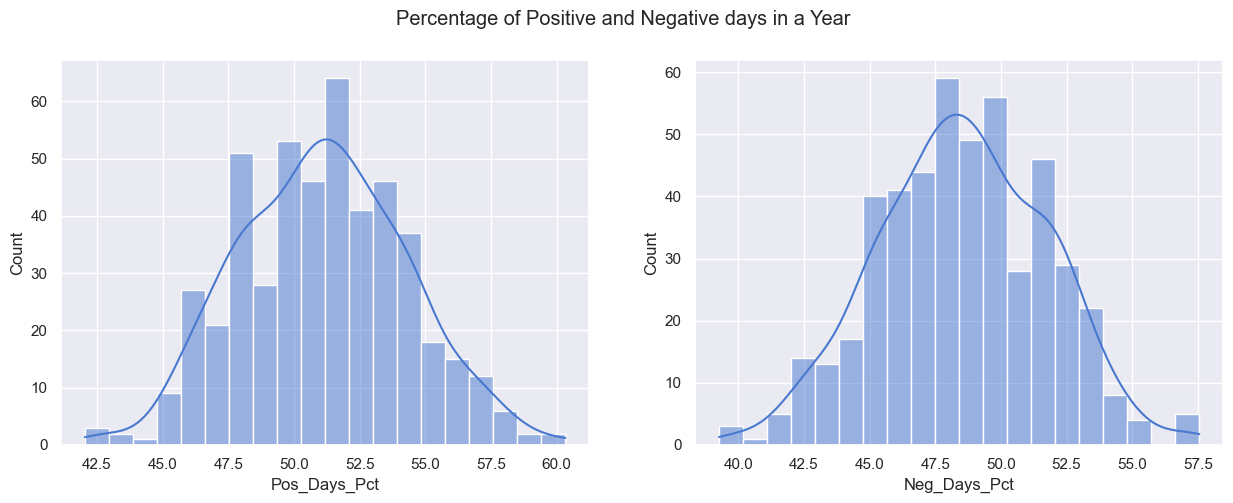

In [124]:
pos_days=dataset['Pos_Days_Pct'].median()
neg_days=dataset['Neg_Days_Pct'].median()

print(f'Typically, Positive days occur {pos_days}% and Negative days occur {neg_days:.2f}% in a year')

diff = pos_days - neg_days

print(f'Hence, positive days are {diff:.2f}% more than negative days in a year.')


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dataset['Pos_Days_Pct'], bins=20, ax=axes[0], kde=True)
sns.histplot(dataset['Neg_Days_Pct'], bins=20, ax=axes[1], kde=True)
plt.suptitle('Percentage of Positive and Negative days in a Year')

plt.show()


The distributions also indicates that positive and negative days occur at fairly similar rates for most stocks.

## 2. Which stocks consistently have high Average Volume

In [125]:
high_avg_vol = dataset[dataset['Avg_Volume'] > dataset['Avg_Volume'].mean()]['Stock'].value_counts().head(10).reset_index()
high_avg_vol.rename(columns={'count':'No of Years'}, inplace=True)
high_avg_vol


,Stock,No of Years
0,BEL,11
1,ITC,11
2,TATASTEEL,11
3,RELIANCE,11
4,SBIN,11
5,ICICIBANK,11
6,BAJFINANCE,9
7,POWERGRID,9
8,WIPRO,8
9,HDFCBANK,7


## 3. What is the distribution of companies across Sectors and Industries?

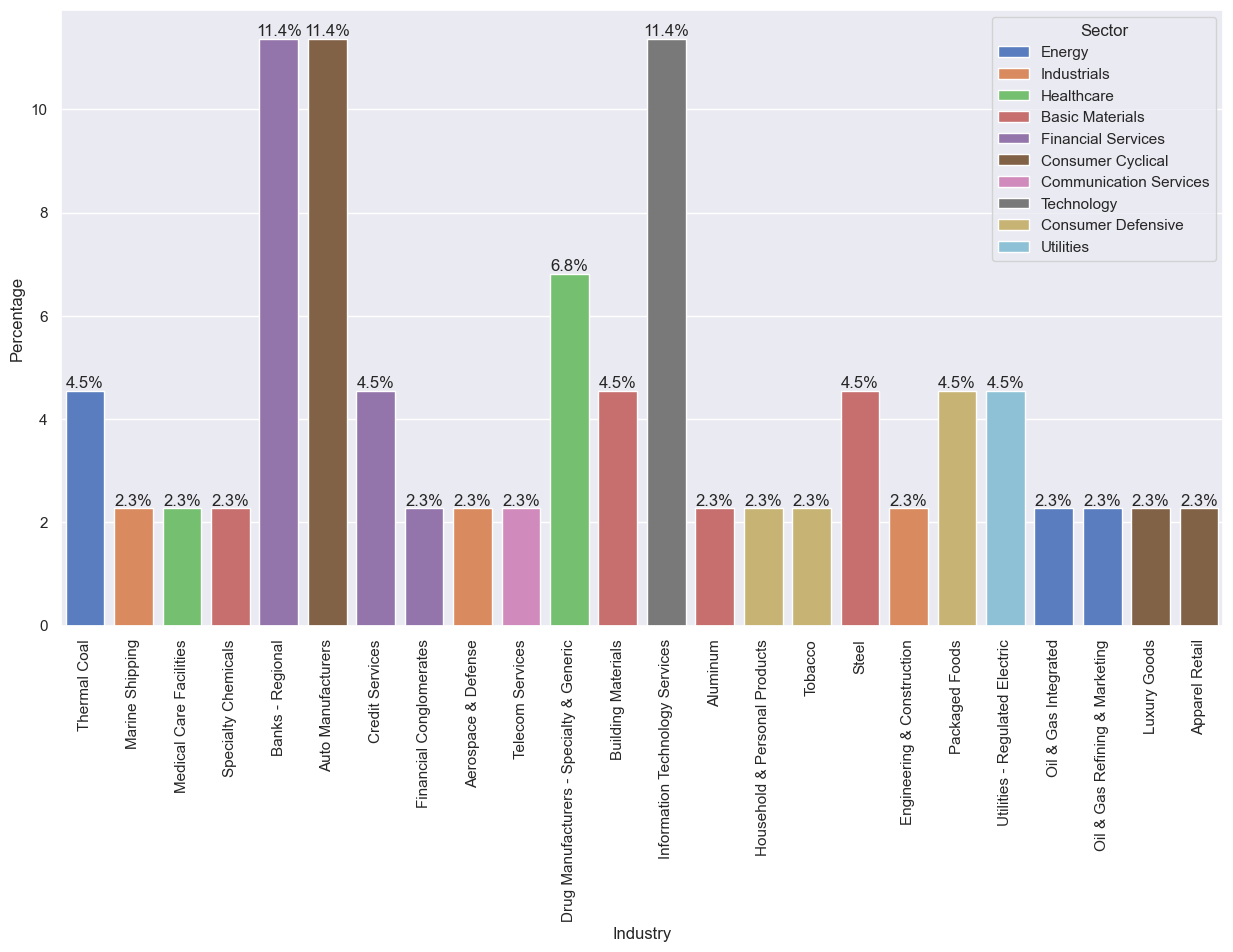

In [126]:
plt.figure(figsize=(15, 8))
ax = sns.countplot(data=dataset, x='Industry', hue='Sector', stat='percent')
[ax.bar_label(c, fmt="%.1f%%") for c in ax.containers]

plt.xticks(rotation=90)
plt.ylabel("Percentage")
plt.show()


1. Top 3 Sectors of stocks in Nifty 50 are - Finanncial Services, Consumer Cyclical and Technology
2. Top 3 Industries of stocks in Nifty 50 are - Banks and Regional, Auto Manufacturers and Information - Technology Services

## 4. How many stocks fall into different Market Cap buckets (e.g., small, mid, large)?

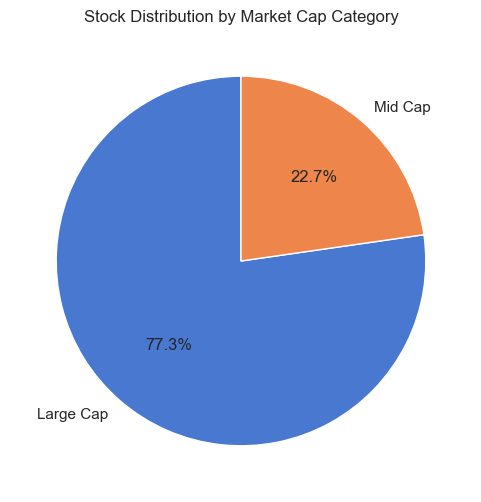

In [127]:
def classify_cap(market_cap):
    if market_cap > 2e12:
        return 'Large Cap'
    elif market_cap >= 5e11:
        return 'Mid Cap'
    else:
        return 'Small Cap'

dataset['Cap_Category'] = dataset['Market Cap'].apply(classify_cap)
cap_counts = dataset['Cap_Category'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(cap_counts, labels=cap_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Stock Distribution by Market Cap Category")
plt.show()


## 5. Which stocks had the highest and lowest annual returns?

In [128]:
high = dataset['Total_Annual_Return'].max()
low = dataset['Total_Annual_Return'].min()
highest_stk = dataset[dataset['Total_Annual_Return']==high]['Stock'].item()
highest_year = dataset[dataset['Total_Annual_Return']==high]['Year'].item()
lowest_stk = dataset[dataset['Total_Annual_Return']==low]['Stock'].item()
lowest_year = dataset[dataset['Total_Annual_Return']==low]['Year'].item()

print(f'{highest_stk} Stock had the Highest Annual Returns of {high:1.2f}% in year {highest_year}')
print(f'{lowest_stk} Stock had the Lowest Annual Returns of {low:1.2f}%  in year {lowest_year}')


ADANIENT Stock had the Highest Annual Returns of 248.28% in year 2021
TATAMOTORS Stock had the Lowest Annual Returns of -59.31%  in year 2018


77.3% of Stocks in Nifty 50 falls under Large Cap and rest of them falls under Mid Cap category. No stocks are under Small Cap category.

## 6. What is the distribution of Total Annual Return across all stocks? 

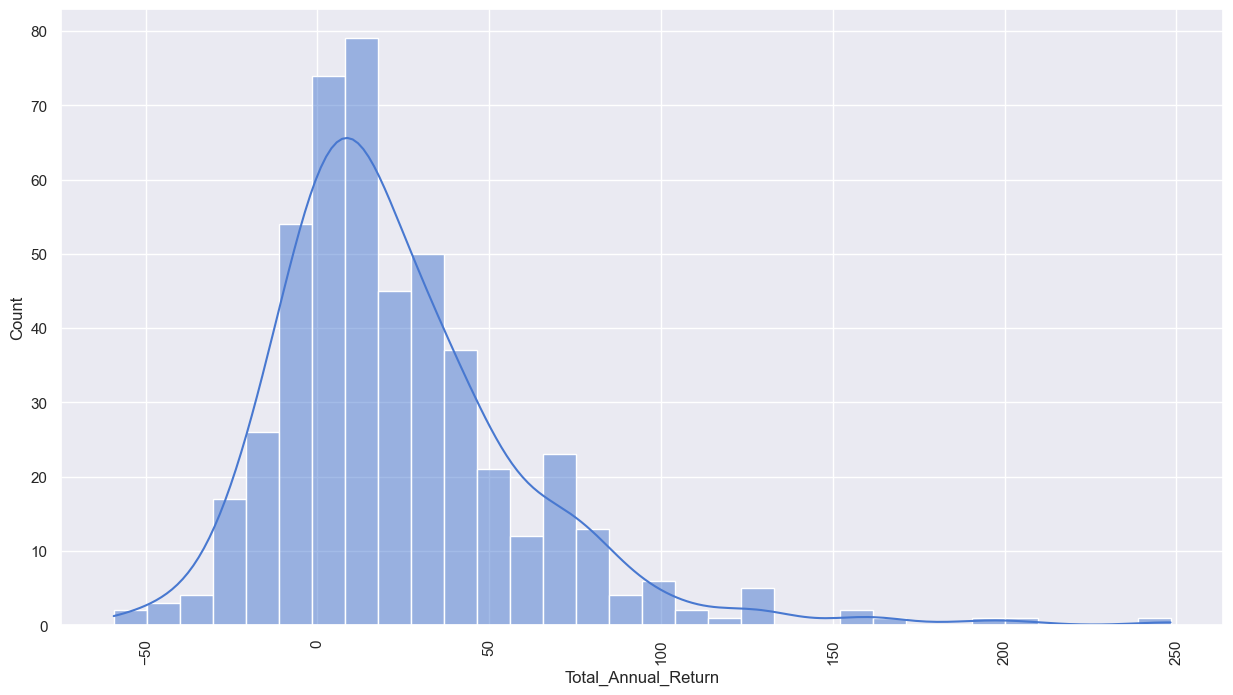

,Mean,Mode,Min,Q1-25th%,Median / Q2-50%,Q3-75th%,99th%,Max-100th%,IQR,1.5rule,LesserRange,GreaterRange,Skew,Kurtosis,Var,Std
Total_Annual_Return,23.3,-59.312056,-59.312056,0.044393,15.645127,38.788296,158.28,248.281489,38.743902,58.115853,-58.07146,96.904149,1.04,1.49,7348.41,1890.0


In [129]:

plt.figure(figsize=(15, 8))
ax = sns.histplot(dataset, x='Total_Annual_Return', kde=True)

plt.xticks(rotation=90)
plt.show()

desc_ann_return = Univariate.descriptive(dataset, ['Total_Annual_Return']).T
desc_ann_return


Most stocks cluster around modest annual returns between –10% and +40%, with a long right tail showing a few outliers delivering very high returns.

## 7. How volatile are stocks based on Standard Deviation of Daily and Monthly Returns?

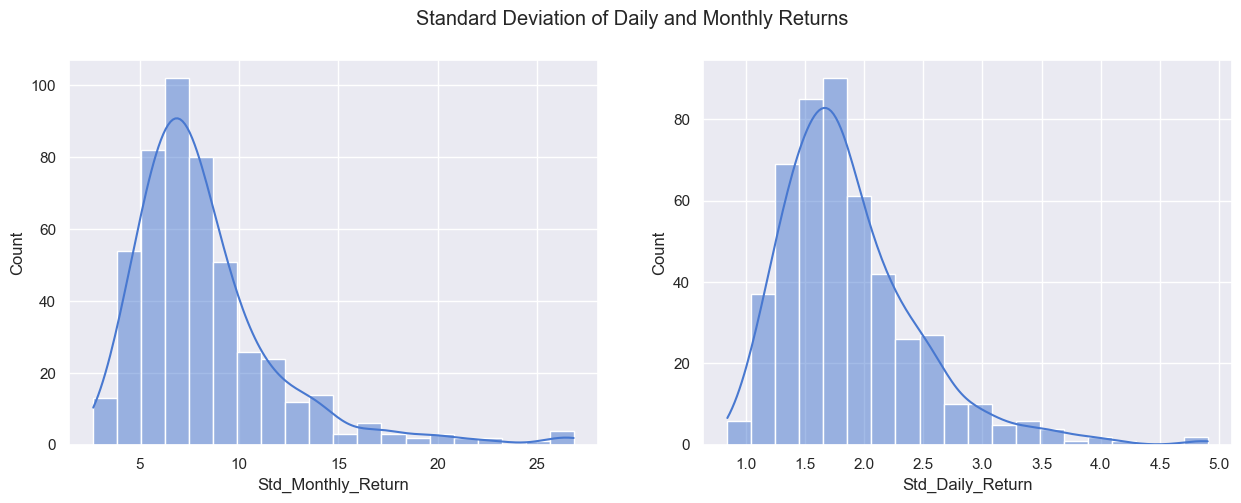

,Mean,Mode,Min,Q1-25th%,Median / Q2-50%,Q3-75th%,99th%,Max-100th%,IQR,1.5rule,LesserRange,GreaterRange,Skew,Kurtosis,Var,Std
Std_Monthly_Return,8.28,2.652248,2.652248,5.971004,7.386997,9.368167,23.16,26.85073,3.397164,5.095746,0.875258,14.463913,1.34,1.13,66.35,17.0
Std_Daily_Return,1.88,0.843603,0.843603,1.472842,1.763431,2.147475,3.86,4.904157,0.674633,1.01195,0.460892,3.159425,1.11,0.79,1.77,1.0


In [130]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(dataset['Std_Monthly_Return'], bins=20, ax=axes[0], kde=True)
sns.histplot(dataset['Std_Daily_Return'], bins=20, ax=axes[1], kde=True)
plt.suptitle('Standard Deviation of Daily and Monthly Returns')

plt.show()

desc_std_return = Univariate.descriptive(dataset, ['Std_Monthly_Return', 'Std_Daily_Return']).T
desc_std_return


Most stocks have low to moderate volatility, with standard deviations of daily and monthly returns clustered at lower values and just a few stocks exhibiting very high volatility.

## 8. Which stocks show unusually biggest move on daily basis

In [131]:
max_tr = dataset[dataset['Max_Daily_TR']>dataset['Max_Daily_TR'].mean()]['Stock'].value_counts().head(6).reset_index()
max_tr = max_tr.rename(columns={'count':'No of Years'})
max_tr


,Stock,No of Years
0,BAJAJ-AUTO,11
1,ULTRACEMCO,11
2,MARUTI,11
3,EICHERMOT,11
4,APOLLOHOSP,9
5,ASIANPAINT,7


## 9. How severe are stock crashes measured by Max Drawdown

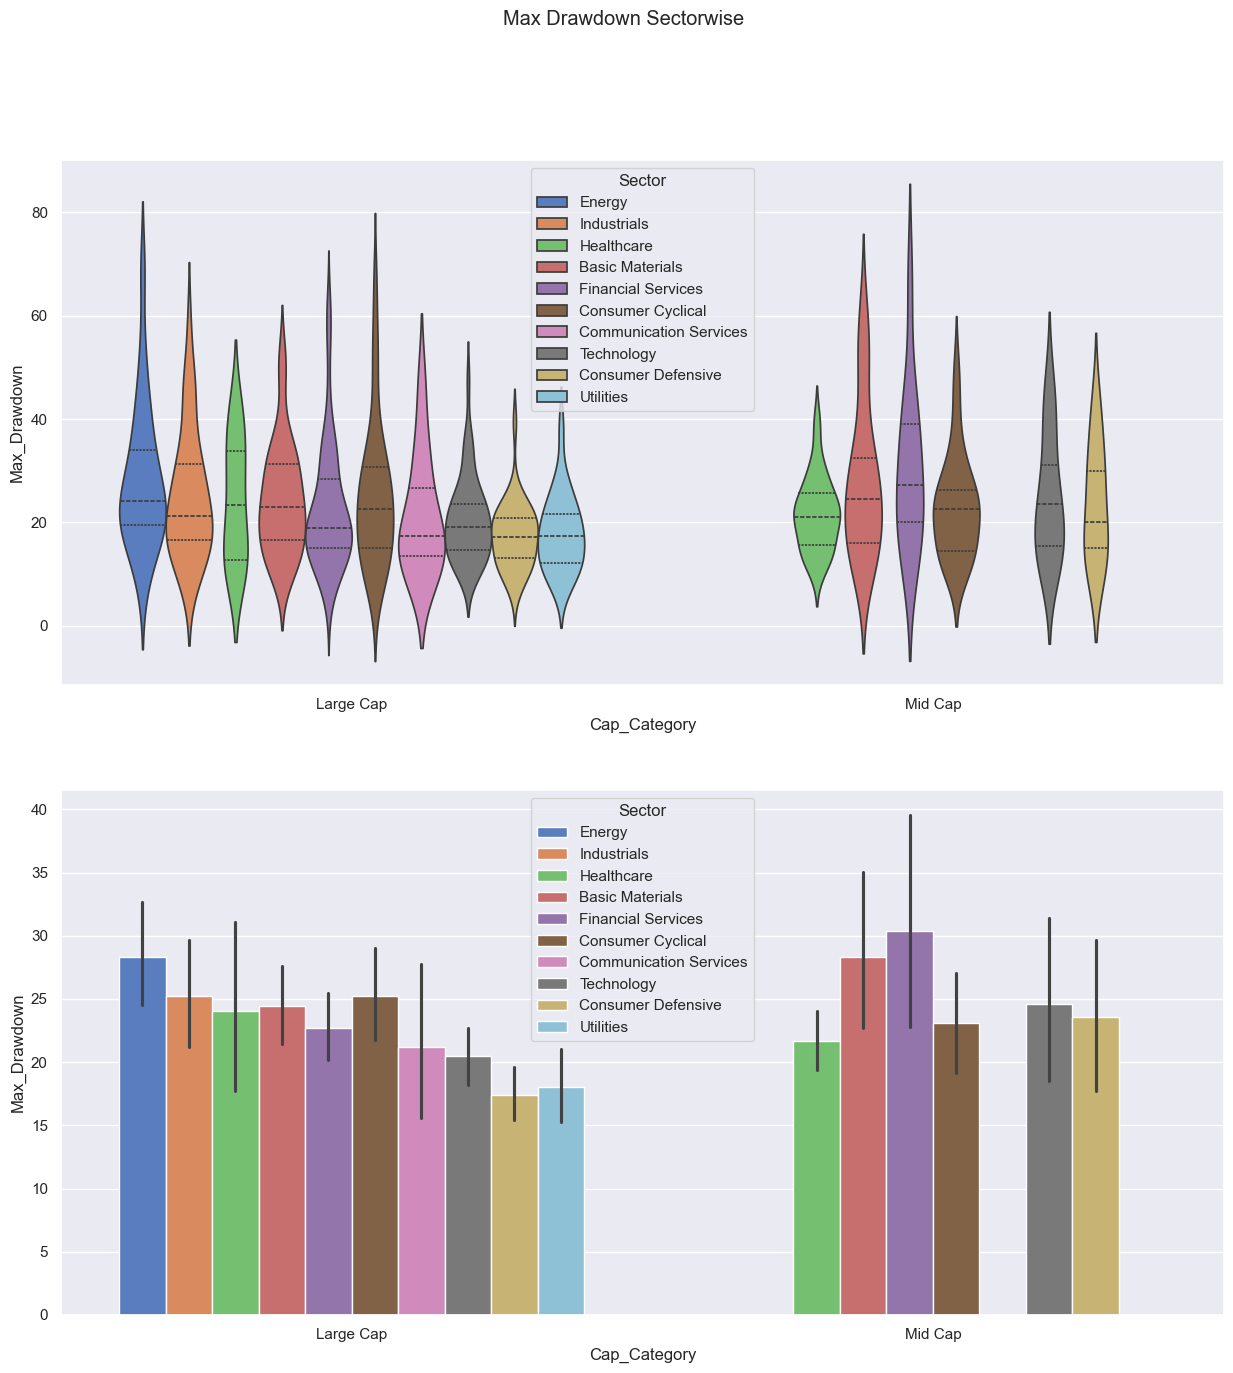

In [132]:
fig, axes = plt.subplots(2, 1, figsize=(15, 15))

# sns.swarmplot(dataset, y='Max_Drawdown', color='lightgreen', ax=axes[0])
sns.violinplot(dataset, y='Max_Drawdown', x='Cap_Category', fill=True, inner='quartile', ax=axes[0], hue='Sector')
sns.barplot(dataset, x='Cap_Category', y='Max_Drawdown', ax=axes[1], hue='Sector', dodge=True)
plt.suptitle('Max Drawdown Sectorwise')

plt.show()


Stock crashes, as measured by Max Drawdown, are generally more severe for Mid Cap stocks, especially in sectors like Communication Services and Consumer Cyclical,, while Large Cap stocks generally have lower and more consistent maximum drawdowns compared to Mid Cap stocks, with defensive sectors like Utilities and Consumer Defensive showing the least crash severity.


## 10. How skewed is the distribution of 12 months Price Momentum

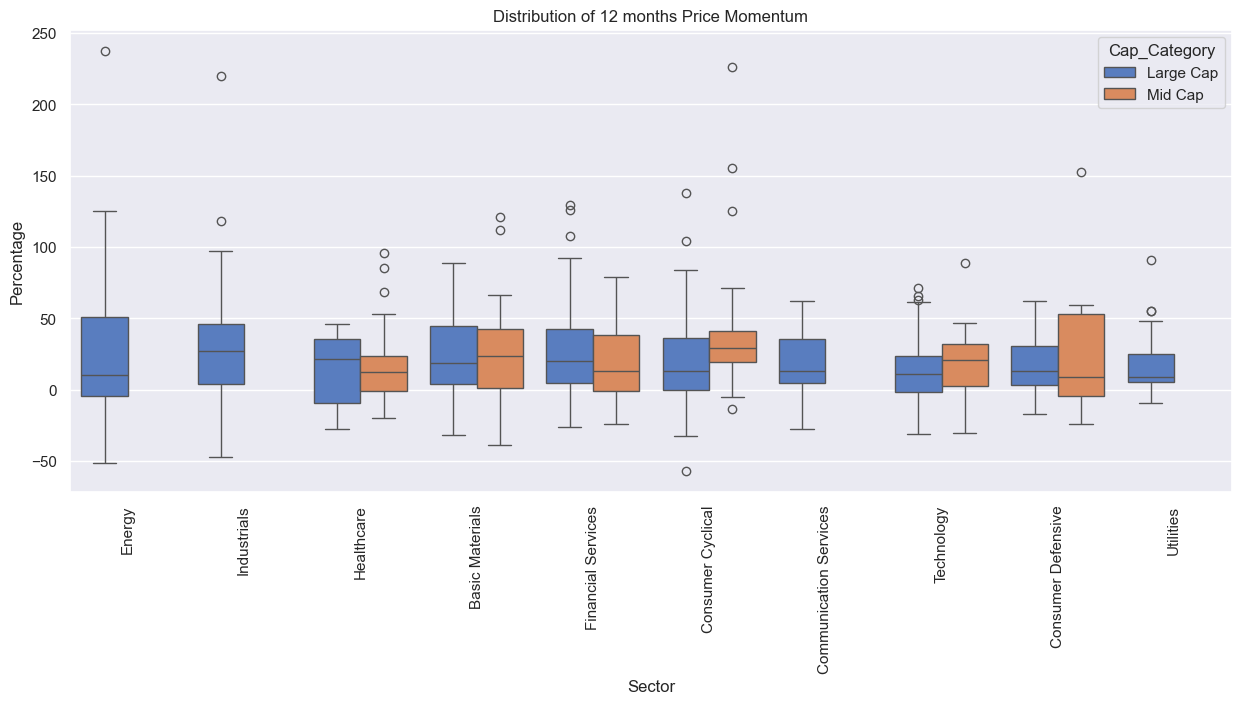

In [133]:
plt.figure(figsize=(15, 6))
sns.boxplot(dataset, y='12M_Momentum', x='Sector', hue='Cap_Category')
plt.title('Distribution of 12 months Price Momentum')
plt.xticks(rotation=90)
plt.ylabel("Percentage")
plt.show()


The momentum distributions are positively skewed in most sectors—medians are closer to the lower quartile and there are more extreme positive outliers—showing that, while most stocks have modest momentum, a few deliver exceptionally high 12-month gains

## 11. How frequent are Volume Spikes across stocks?

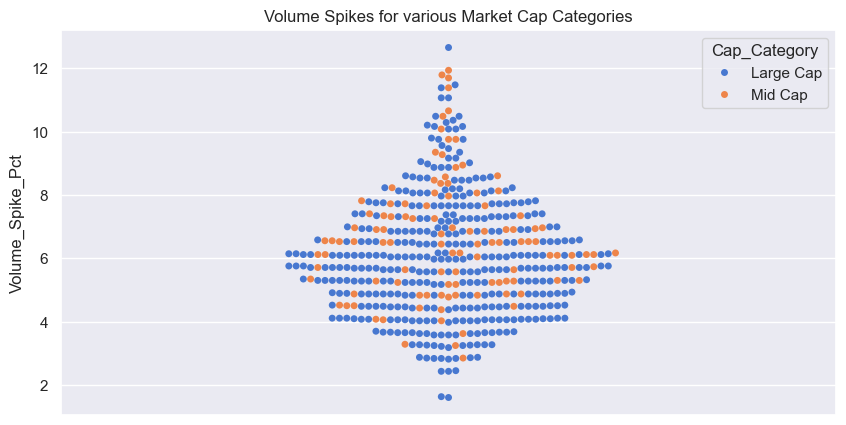

In [134]:
plt.figure(figsize=[10,5])
sns.swarmplot(dataset, y='Volume_Spike_Pct', hue='Cap_Category')
plt.title('Volume Spikes for various Market Cap Categories')
plt.show()


Volume spikes occur with similar frequency for both Large Cap and Mid Cap stocks, with most stocks experiencing spikes on 4% to 8% of trading days and a few outliers exceeding 10%

## 12. What is the distribution of Beta vs NIFTY across sectors?

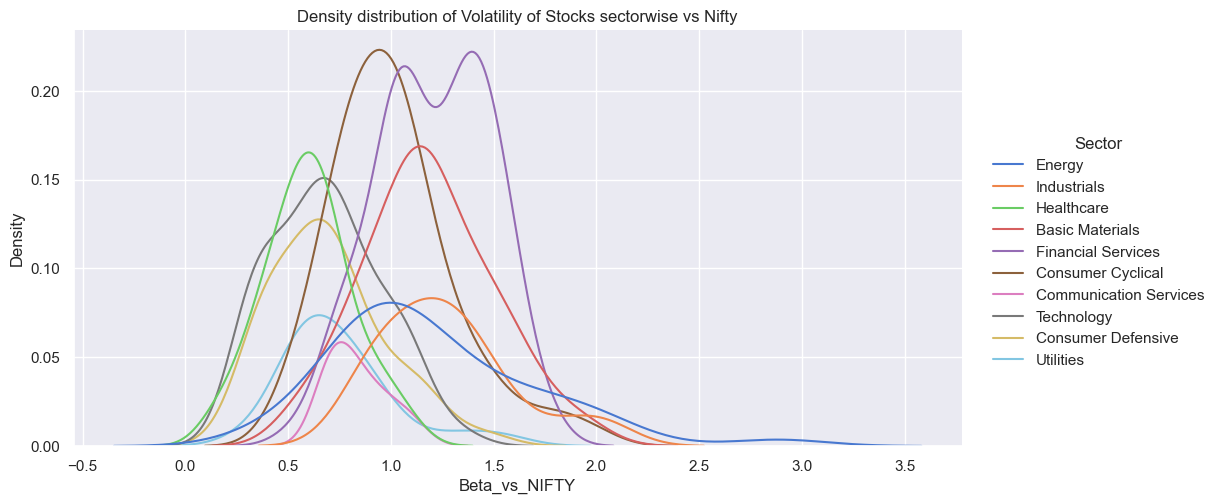

In [135]:
sns.displot(dataset, x='Beta_vs_NIFTY', kind='kde', hue='Sector', aspect=2)
plt.title('Density distribution of Volatility of Stocks sectorwise vs Nifty')
plt.show()


Communication Services stocks have the lowest Beta vs NIFTY, sharply concentrated near 1, meaning their volatility is typically equal to the market.

Healthcare, Utilities, and Consumer Defensive sectors have lower Beta distributions, peaking around 0.5–0.7, indicating they are stable sectors.

Most other sectors, such as Energy, Industrials, and Financial Services, have much broader Beta distributions (spread from below 0.5 up to 2+), meaning there’s a wide mix of both low- and high-volatile stocks within those sectors.

## 13. How does Avg Volume vary by Industry?

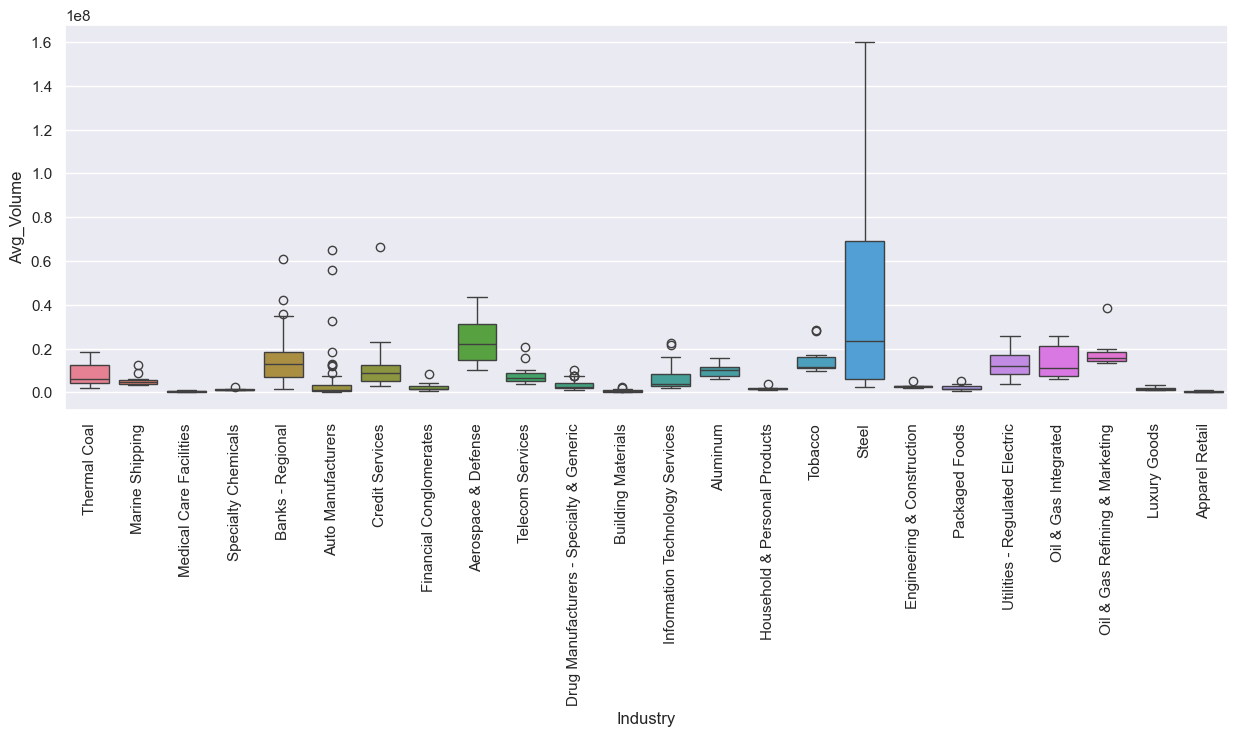

In [136]:
plt.figure(figsize=[15,5])
sns.boxplot(dataset, y='Avg_Volume', x='Industry', hue='Industry', legend=False)
plt.xticks(rotation=90)
plt.show()


Steel has the highest and most variable average trading volume among all industries, while most other industries show much lower and more consistent volumes. This suggests Steel stocks are traded much more actively

## 14. What is the Sectorwise Stocks Correlation with Nifty?

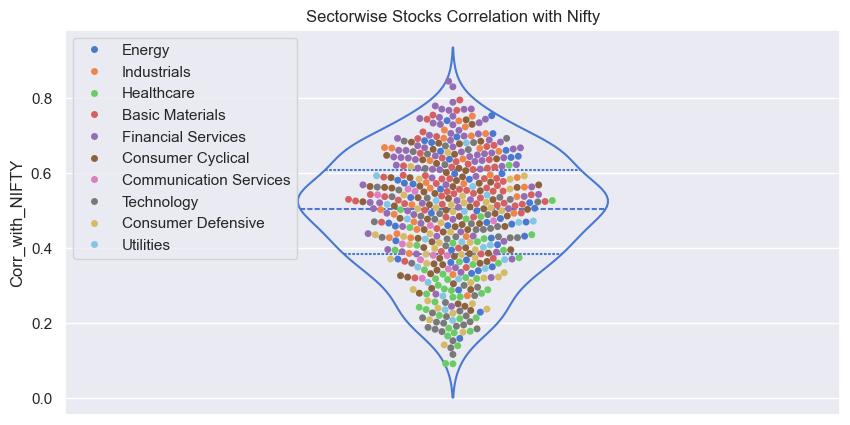

In [137]:
plt.figure(figsize=[10,5])
sns.violinplot(dataset, y='Corr_with_NIFTY', fill=False, inner='quart', width=0.4)
sns.swarmplot(dataset,y='Corr_with_NIFTY', hue='Sector')
plt.title('Sectorwise Stocks Correlation with Nifty')
plt.legend(loc='upper left')
plt.show()


Most stocks have a moderate correlation with Nifty, clustering around 0.4 to 0.6, regardless of sector. This means most sectors partially move with the market, though considerable variation exists among individual stocks.

## 15.  Does a higher Max Drawdown correlate with higher/lower Annual Return?

Total Annual Return Decreases when Max Drawdown increases (correlation: -0.39)


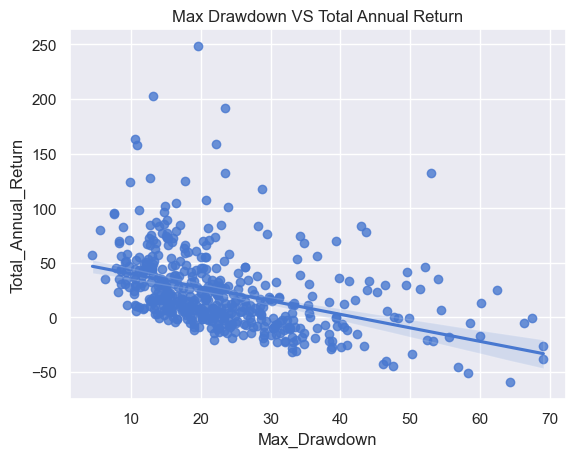

In [138]:
drdown_annreturn = dataset[['Max_Drawdown','Total_Annual_Return']].corr()
result=drdown_annreturn['Max_Drawdown']['Total_Annual_Return'].item()

print(f'Total Annual Return Increases when Max Drawdown increases (correlation: {result:.2f})' if result >0 else f'Total Annual Return Decreases when Max Drawdown increases (correlation: {result:.2f})')

sns.regplot(dataset, x='Max_Drawdown', y='Total_Annual_Return')
plt.title('Max Drawdown VS Total Annual Return')
plt.show()


The negative correlation means when Maximum Drawdown increases (larger losses), the Total Annual Return tends to decrease.

## 16. Do Stocks with higher Volume Spike % have higher Avg Volume

Average Volume tends to decrease as Volume Spike Percent increases (correlation: -0.07)


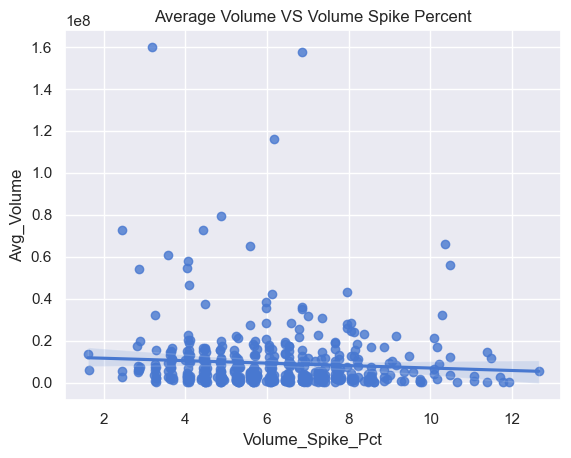

In [139]:
volspike_avgvol = dataset[['Volume_Spike_Pct','Avg_Volume']].corr()
result=volspike_avgvol['Volume_Spike_Pct']['Avg_Volume'].item()

print(f'Average Volume tends to increase as Volume Spike Percent increases (correlation: {result:.2f})' if result > 0 else f'Average Volume tends to decrease as Volume Spike Percent increases (correlation: {result:.2f})')


sns.regplot(dataset, x='Volume_Spike_Pct', y='Avg_Volume')
plt.title('Average Volume VS Volume Spike Percent')
plt.show()


## 17. Does Market Cap affect Total Annual Return


p-value: 0.628 hence, we fail to reject the null hypothesis (Market Cap does not affect Total Annual Return)


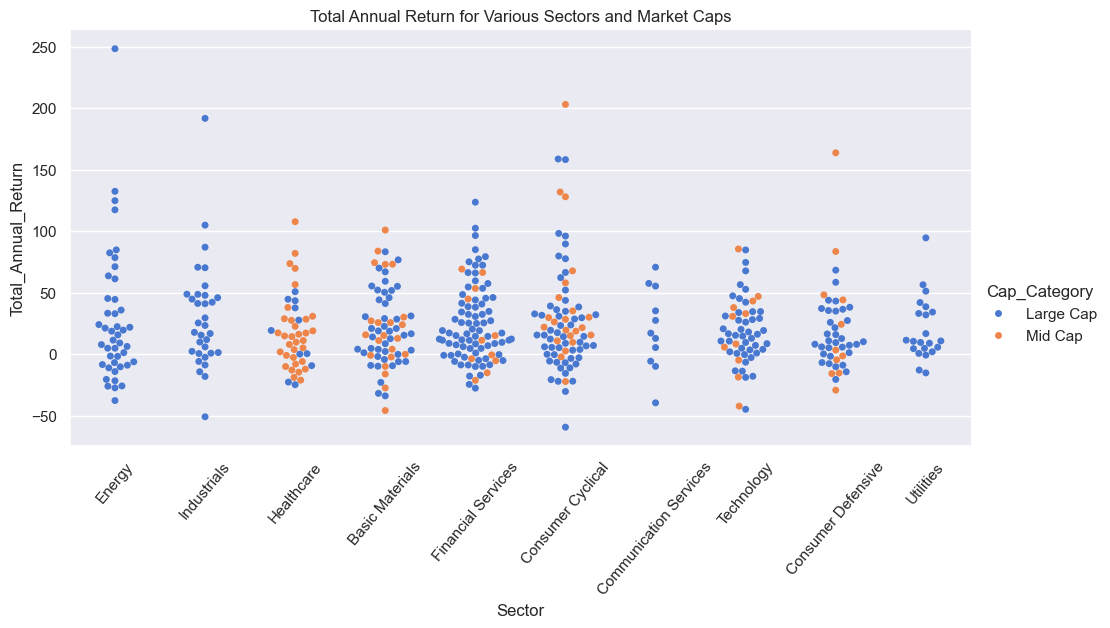

In [140]:
large = dataset[dataset['Cap_Category'] == 'Large Cap']['Total_Annual_Return']
mid = dataset[dataset['Cap_Category'] == 'Mid Cap']['Total_Annual_Return']

test = ttest_ind(large, mid)

if test[1] < 0.05:
    print("\np-value:", test[1].round(3), 'hence, we reject the null hypothesis (Market Cap affects Total Annual Return)')
else:
    print("\np-value:", test[1].round(3), 'hence, we fail to reject the null hypothesis (Market Cap does not affect Total Annual Return)')

sns.catplot(dataset, x='Sector', y='Total_Annual_Return', kind='swarm', aspect=2, hue='Cap_Category')
plt.xticks(rotation=50)
plt.title('Total Annual Return for Various Sectors and Market Caps')
plt.show()


## 18. How many Stocks fall under each Sector and Industry?

In [212]:
stk_category=(dataset.groupby(['Sector', 'Industry', 'Stock']).count().reset_index()) [['Sector', 'Industry', 'Stock']]

fig_pie = px.pie(
    stk_category, 'Sector',
    hole=0.5
)
fig_pie.update_traces(textinfo='label + percent', textposition='outside', showlegend=False)

fig_pie.show()


In [ ]:
fig_sunburst = px.sunburst(
    stk_category,
    path=['Sector', 'Industry', 'Stock'],
    title='SunBurst Chart: Sector > Industry > Stock',
    width=1100,
    height=600
)

fig_sunburst.show()


## 19. How do quantitative features in the dataset relate to each other?

In [230]:
quan1=['Market Cap', 'Total_Annual_Return', 'Avg_Monthly_Return',
       'Std_Monthly_Return']
quan2=[ 'Max_Drawdown', 'Std_Daily_Return',
       'Pos_Days_Pct', 'Neg_Days_Pct',]
quan3=['Avg_Daily_TR', 'Max_Daily_TR',
       'Avg_Volume', 'Volume_Spike_Pct',]
quan4=[ '12M_Momentum', 'Months_Pos_Pct',
       'Beta_vs_NIFTY', 'Corr_with_NIFTY']


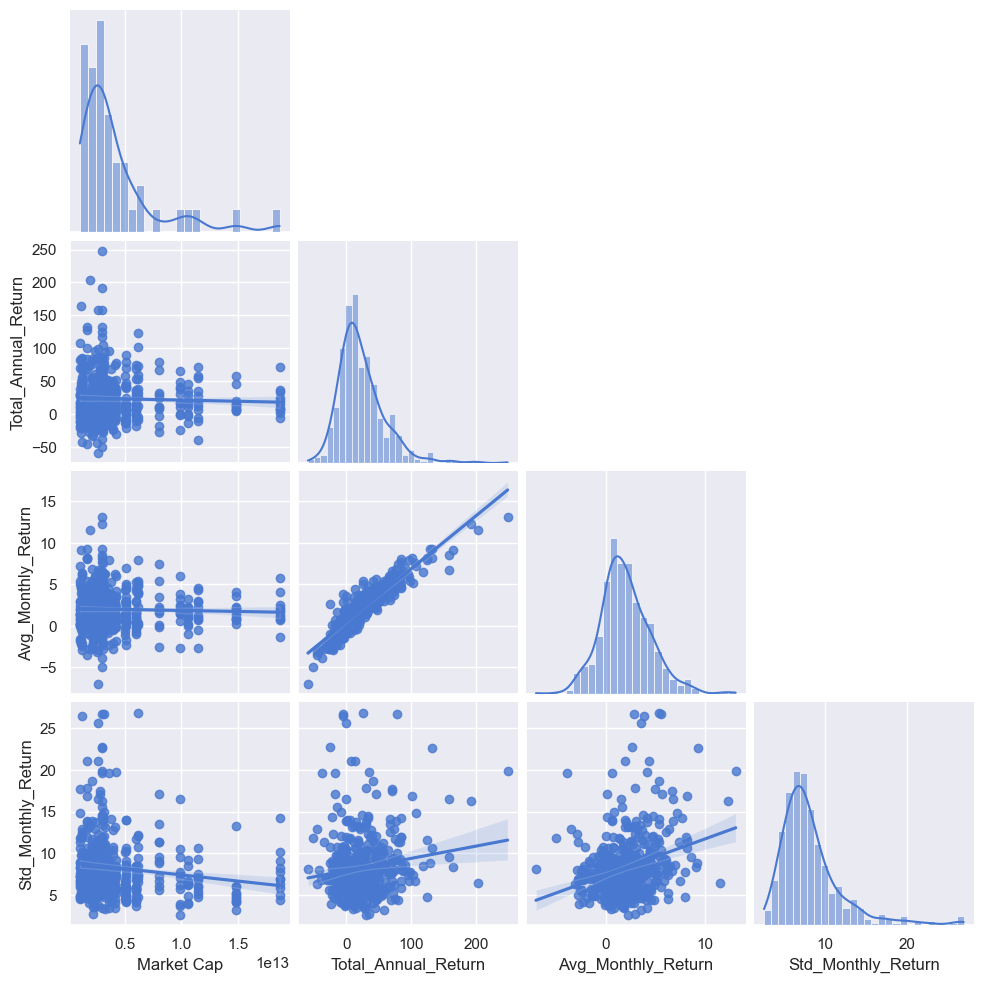

In [233]:
sns.pairplot(dataset[quan1], corner=True, kind='reg',diag_kws={'kde':True})
plt.show()


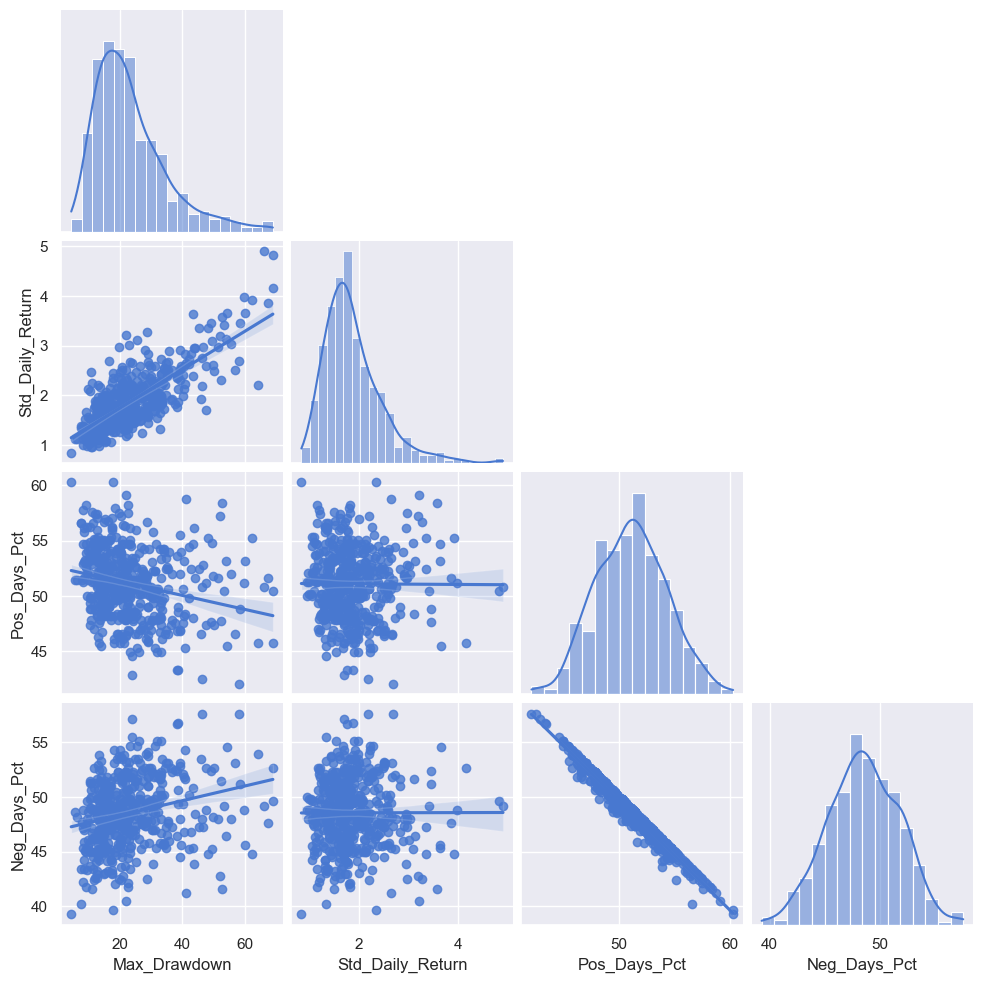

In [234]:
sns.pairplot(dataset[quan2], corner=True, kind='reg',diag_kws={'kde':True})
plt.show()


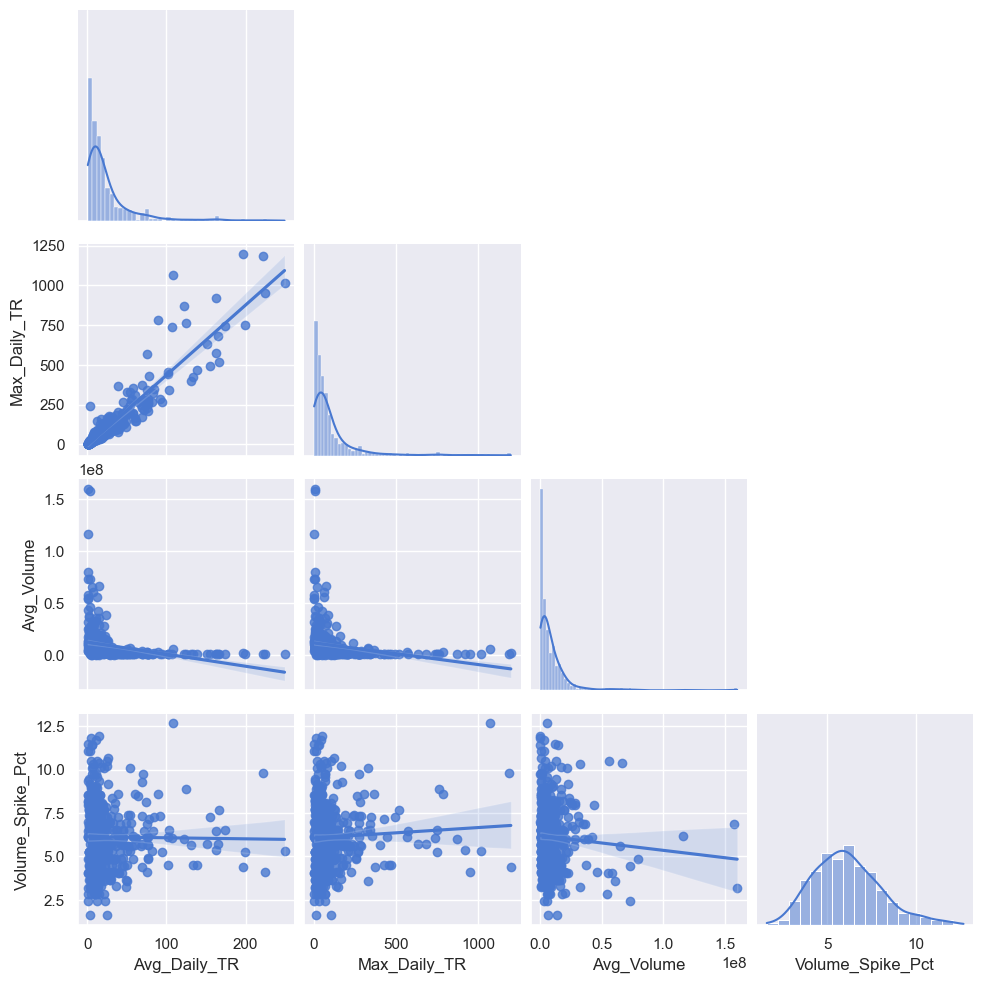

In [235]:
sns.pairplot(dataset[quan3], corner=True, kind='reg',diag_kws={'kde':True})
plt.show()


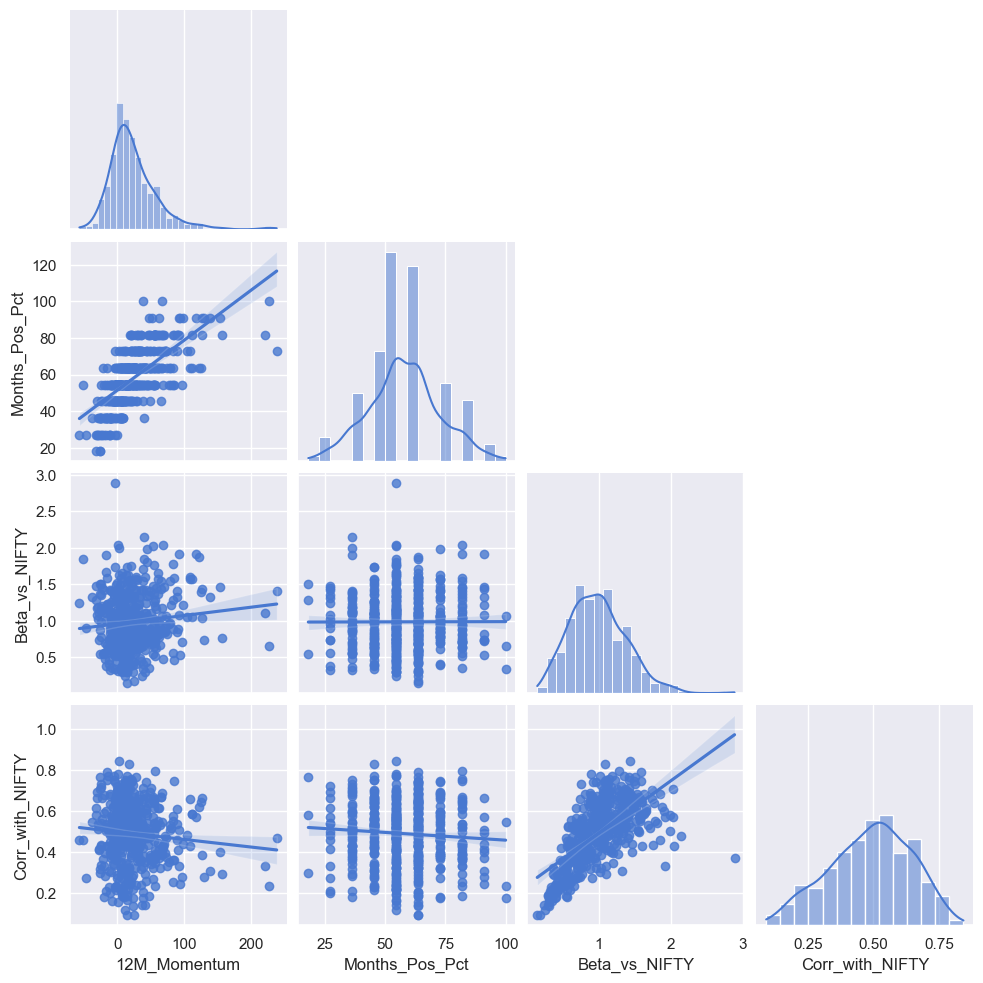

In [236]:
sns.pairplot(dataset[quan4], corner=True, kind='reg',diag_kws={'kde':True})
plt.show()


## 20. Correlation of each features to each other

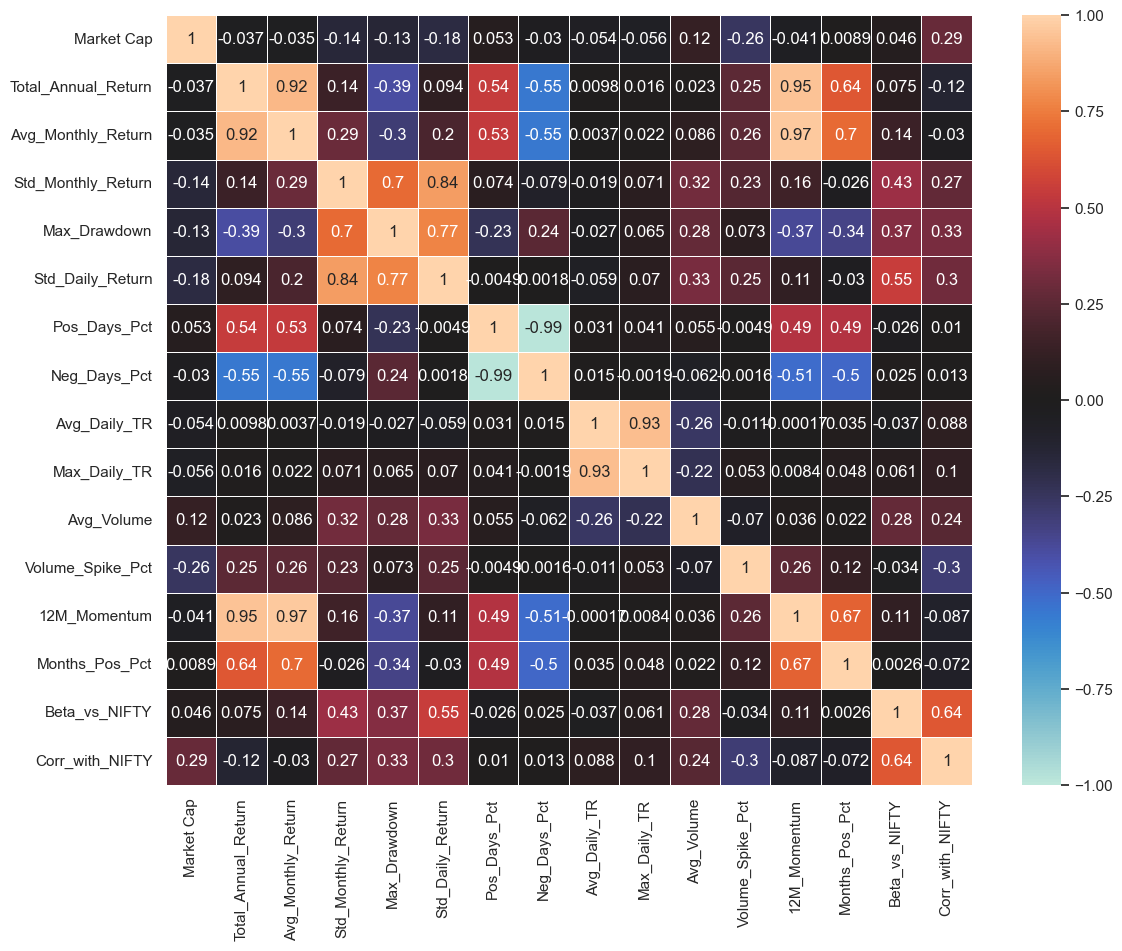

In [ ]:
data_corr=dataset[quan].corr()
plt.figure(figsize=[13,10])
sns.heatmap(data_corr, vmax=1, vmin=-1, center=0, annot=True, linewidths=0.5)
plt.show()


Total_Annual_Return is strongly positively correlated with Avg_Monthly_Return and Months_Pos_Pct, and strongly negatively correlated with Max_Drawdown, indicating better returns come with more positive months and smaller drawdowns. Beta_vs_NIFTY and Corr_with_NIFTY have a high positive correlation, while Pos_Days_Pct and Neg_Days_Pct are, as expected, highly negatively correlated.